# JD.com Search and Shopping Behavior Analysis

## Project Objective

This project analyzes customer search and shopping interaction data from the JDsearch dataset to identify patterns in product discovery, engagement, and purchasing activity.

The analysis focuses on how recorded positive interactions are distributed across products, categories, brands, shops, and search queries. The goal is to identify high-performing segments as well as areas with substantial engagement but relatively low purchase representation that may warrant further investigation.

Because the dataset does not provide linked customer journeys, timestamps, or non-interaction impressions, the analysis is descriptive rather than causal. Results are intended to support prioritization and follow-up investigation rather than demonstrate that a particular factor caused a purchase.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Project environment is ready!")

Project environment is ready!


## Dataset Scope

The analytical dataset contains recorded positive customer interactions associated with search results and products. The interaction labels represent:

- **1 — Click**
- **2 — Add to Cart**
- **3 — Purchase**

Records representing no interaction are not included in the processed dataset. Therefore, the analysis does not measure traditional conversion from impressions, visitors, or sessions.

The primary metric used throughout the project is **Purchase Share**, defined as:

**Purchases ÷ Recorded Positive Interactions**

Purchase Share should not be interpreted as a conventional e-commerce conversion rate.

The dataset also contains anonymized identifiers for products, brands, shops, categories, queries, and interaction records. Search-query content is tokenized, which limits semantic interpretation of individual searches.

In [2]:
df = pd.read_parquet("processed_with_meta.parquet")

print("Rows and columns:", df.shape)
df.head()

Rows and columns: (320132, 10)


,query,candidates,labels,c_id,q_id,wid,name,brand_id,cate_id_4,shop_id
0,63995226602574196100244625575117,36098226,1.0,0,0,36098226,63995226727690576025741989923027163848132...,44571440,22195176,15887164
1,1254963427438884,30857980,1.0,1,1,30857980,22066509278253303424581160257419590565387...,33490138,10138475,48380459
2,1254963427438884,44577431,1.0,2,1,44577431,72360213602574191254963427438884838430146...,82873120,90597144,50470304
3,24374376067768939206305,90092899,1.0,4,2,90092899,89583827243743747694022730184349163322639...,23790996,56253428,72752062
4,29463948632095349356845164880503931105432...,97234676,1.0,5,3,97234676,29463948417877055621806859865766969458129...,31286128,28122822,27155839


## Data Validation

Before transforming the dataset, I reviewed its structure, data types, summary statistics, and missing-value patterns. These checks were used to verify that the imported data was suitable for analysis and to identify fields requiring renaming, type conversion, or additional validation.

The validation process includes:

- reviewing dataset dimensions and sample records;
- inspecting column data types;
- checking descriptive statistics;
- identifying missing values; and
- verifying the structure of identifier and interaction fields.

In [3]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 320132 entries, 0 to 320131
Data columns (total 10 columns):
 #   Column      Non-Null Count   Dtype  
---  ------      --------------   -----  
 0   query       320132 non-null  str    
 1   candidates  320132 non-null  int64  
 2   labels      320132 non-null  float64
 3   c_id        320132 non-null  int64  
 4   q_id        320132 non-null  int64  
 5   wid         320132 non-null  int64  
 6   name        320132 non-null  str    
 7   brand_id    320132 non-null  int64  
 8   cate_id_4   320132 non-null  int64  
 9   shop_id     320132 non-null  int64  
dtypes: float64(1), int64(7), str(2)
memory usage: 107.6 MB


In [4]:
df.describe()


,candidates,labels,c_id,q_id,wid,brand_id,cate_id_4,shop_id
count,3.201320e+05,320132.000000,320132.000000,320132.000000,3.201320e+05,3.201320e+05,3.201320e+05,3.201320e+05
mean,5.012701e+07,1.365596,100938.537956,43218.350121,5.012701e+07,5.051773e+07,4.862482e+07,4.983436e+07
std,2.901665e+07,0.601650,71397.685840,33754.762392,2.901665e+07,2.775026e+07,2.975056e+07,2.890819e+07
min,2.000000e+00,1.000000,0.000000,0.000000,2.000000e+00,2.087000e+03,5.614000e+03,-1.000000e+00
25%,2.497799e+07,1.000000,35878.000000,11975.750000,2.497799e+07,2.870936e+07,2.310928e+07,2.506394e+07
50%,5.013459e+07,1.000000,92506.500000,36742.000000,5.013459e+07,5.200249e+07,4.896508e+07,4.899140e+07
75%,7.541142e+07,2.000000,161457.250000,71345.250000,7.541142e+07,7.253744e+07,7.425160e+07,7.529158e+07
max,9.999897e+07,3.000000,238499.000000,111555.000000,9.999897e+07,9.999861e+07,9.994639e+07,9.999974e+07


In [5]:
df.describe(include='all')

,query,candidates,labels,c_id,q_id,wid,name,brand_id,cate_id_4,shop_id
count,320132,3.201320e+05,320132.000000,320132.000000,320132.000000,3.201320e+05,320132,3.201320e+05,3.201320e+05,3.201320e+05
unique,110393,NaN,NaN,NaN,NaN,NaN,236268,NaN,NaN,NaN
top,59054959,NaN,NaN,NaN,NaN,NaN,56013487602574192735938976730543602574196...,NaN,NaN,NaN
freq,581,NaN,NaN,NaN,NaN,NaN,396,NaN,NaN,NaN
mean,NaN,5.012701e+07,1.365596,100938.537956,43218.350121,5.012701e+07,NaN,5.051773e+07,4.862482e+07,4.983436e+07
std,NaN,2.901665e+07,0.601650,71397.685840,33754.762392,2.901665e+07,NaN,2.775026e+07,2.975056e+07,2.890819e+07
min,NaN,2.000000e+00,1.000000,0.000000,0.000000,2.000000e+00,NaN,2.087000e+03,5.614000e+03,-1.000000e+00
25%,NaN,2.497799e+07,1.000000,35878.000000,11975.750000,2.497799e+07,NaN,2.870936e+07,2.310928e+07,2.506394e+07
50%,NaN,5.013459e+07,1.000000,92506.500000,36742.000000,5.013459e+07,NaN,5.200249e+07,4.896508e+07,4.899140e+07
75%,NaN,7.541142e+07,2.000000,161457.250000,71345.250000,7.541142e+07,NaN,7.253744e+07,7.425160e+07,7.529158e+07


In [6]:
df.isnull().sum()

query         0
candidates    0
labels        0
c_id          0
q_id          0
wid           0
name          0
brand_id      0
cate_id_4     0
shop_id       0
dtype: int64

## Data Cleaning and Preparation

A separate working DataFrame was created so that the imported source data remained unchanged during transformation.

The cleaning process standardizes column names, converts identifier fields to consistent data types, validates relationships between source identifiers, and creates analysis-friendly interaction fields.

Several decisions are especially important to the analysis:

- The source candidate-product identifier was compared with `product_id` before the redundant field was removed.
- Interaction labels were mapped to descriptive categories: Click, Add to Cart, and Purchase.
- Binary fields were created to support aggregation of purchases and cart-or-purchase interactions.
- Product, brand, category, shop, query-record, and candidate-record identifiers were standardized for consistent grouping and comparison.

In [7]:
clean_df = df.copy()

clean_df =clean_df.rename(columns={
    "candidates": "candidate_product_id",
    "labels": "interaction_label",
    "c_id": "candidate_record_id",
    "q_id": "query_record_id",
    "wid": "product_id",
    "name": "product_name_tokens",
    "cate_id_4": "category_level_4_id"
})

clean_df.head()


,query,candidate_product_id,interaction_label,candidate_record_id,query_record_id,product_id,product_name_tokens,brand_id,category_level_4_id,shop_id
0,63995226602574196100244625575117,36098226,1.0,0,0,36098226,63995226727690576025741989923027163848132...,44571440,22195176,15887164
1,1254963427438884,30857980,1.0,1,1,30857980,22066509278253303424581160257419590565387...,33490138,10138475,48380459
2,1254963427438884,44577431,1.0,2,1,44577431,72360213602574191254963427438884838430146...,82873120,90597144,50470304
3,24374376067768939206305,90092899,1.0,4,2,90092899,89583827243743747694022730184349163322639...,23790996,56253428,72752062
4,29463948632095349356845164880503931105432...,97234676,1.0,5,3,97234676,29463948417877055621806859865766969458129...,31286128,28122822,27155839


In [8]:
product_ids_match = (
    clean_df["candidate_product_id"] == clean_df["product_id"]
).all()

print("Do candidate_product_id and product_id always match?", product_ids_match)

Do candidate_product_id and product_id always match? True


In [9]:
clean_df = clean_df.drop(columns=["candidate_product_id"])

In [10]:
interaction_mapping = {
    1: "Click",
    2: "Add to Cart",
    3: "Purchase"
}

clean_df["interaction_label"] = clean_df["interaction_label"].astype("int8")

clean_df["interaction_type"] = (
    clean_df["interaction_label"]
    .map(interaction_mapping)
)

clean_df["added_to_cart_or_purchased"] = (
    clean_df["interaction_label"] >= 2
).astype("int8")

clean_df["purchased"] = (
    clean_df["interaction_label"] == 3
).astype("int8")

clean_df[
    [
        "interaction_label",
        "interaction_type",
        "added_to_cart_or_purchased",
        "purchased"
    ]
].head(10)

,interaction_label,interaction_type,added_to_cart_or_purchased,purchased
0,1,Click,0,0
1,1,Click,0,0
2,1,Click,0,0
3,1,Click,0,0
4,1,Click,0,0
5,1,Click,0,0
6,1,Click,0,0
7,1,Click,0,0
8,1,Click,0,0
9,1,Click,0,0


In [11]:
id_columns = [
    "product_id",
    "brand_id",
    "category_level_4_id",
    "shop_id",
    "candidate_record_id",
    "query_record_id"
]

for column in id_columns:
    clean_df[column] = clean_df[column].astype("string")

clean_df.dtypes

query                            str
interaction_label               int8
candidate_record_id           string
query_record_id               string
product_id                    string
product_name_tokens              str
brand_id                      string
category_level_4_id           string
shop_id                       string
interaction_type                 str
added_to_cart_or_purchased      int8
purchased                       int8
dtype: object

In [12]:
print(clean_df.columns.tolist())

['query', 'interaction_label', 'candidate_record_id', 'query_record_id', 'product_id', 'product_name_tokens', 'brand_id', 'category_level_4_id', 'shop_id', 'interaction_type', 'added_to_cart_or_purchased', 'purchased']


In [13]:
clean_df = clean_df.rename(columns={
    "cate_id_4": "category_level_4_id"
})

# Convert only ID columns that actually exist
id_columns = [
    "product_id",
    "brand_id",
    "category_level_4_id",
    "shop_id",
    "candidate_record_id",
    "query_record_id"
]

for column in id_columns:
    if column in clean_df.columns:
        clean_df[column] = clean_df[column].astype("string")
    else:
        print(f"Column not found: {column}")

clean_df.dtypes



query                            str
interaction_label               int8
candidate_record_id           string
query_record_id               string
product_id                    string
product_name_tokens              str
brand_id                      string
category_level_4_id           string
shop_id                       string
interaction_type                 str
added_to_cart_or_purchased      int8
purchased                       int8
dtype: object

In [14]:
interaction_summary = (
    clean_df["interaction_type"]
    .value_counts()
    .reindex(["Click", "Add to Cart", "Purchase"], fill_value=0)
    .rename_axis("interaction_type")
    .reset_index(name="interaction_count")
)

interaction_summary["percentage"] = (
    interaction_summary["interaction_count"]
    / interaction_summary["interaction_count"].sum()
    * 100
).round(2)

interaction_summary

,interaction_type,interaction_count,percentage
0,Click,223909,69.94
1,Add to Cart,75407,23.55
2,Purchase,20816,6.50


In [15]:
print("Total interactions:", len(clean_df))
print("Unique query records:", clean_df["query_record_id"].nunique())
print("Unique products:", clean_df["product_id"].nunique())
print("Unique brands:", clean_df["brand_id"].nunique())
print("Unique categories:", clean_df["category_level_4_id"].nunique())
print("Unique shops:", clean_df["shop_id"].nunique())
print("Duplicate rows:", clean_df.duplicated().sum())

Total interactions: 320132
Unique query records: 110393
Unique products: 237814
Unique brands: 47757
Unique categories: 4777
Unique shops: 78976
Duplicate rows: 16575


In [16]:
print("Total interactions:", len(clean_df))
print("Unique query records:", clean_df["query_record_id"].nunique())
print("Unique products:", clean_df["product_id"].nunique())
print("Unique brands:", clean_df["brand_id"].nunique())
print("Unique categories:", clean_df["category_level_4_id"].nunique())
print("Unique shops:", clean_df["shop_id"].nunique())
print("Duplicate rows:", clean_df.duplicated().sum())


Total interactions: 320132
Unique query records: 110393
Unique products: 237814
Unique brands: 47757
Unique categories: 4777
Unique shops: 78976
Duplicate rows: 16575


## Duplicate-Row Sensitivity Analysis

The cleaned dataset contains 16,575 exact duplicate rows, representing approximately 5.18% of the 320,132 recorded interactions. These records were not automatically removed because the source data does not include timestamps or a unique event-level identifier. As a result, identical rows cannot be conclusively classified as accidental duplicates rather than legitimate repeated customer interactions.

To evaluate whether retaining these records materially affects the analysis, a sensitivity test was performed by creating a deduplicated version of the dataset and recalculating the headline Purchase Share metric. The deduplicated dataset is used only for comparison; the original cleaned dataset remains the basis for the primary analysis.

In [17]:
# Duplicate-row sensitivity analysis

total_rows = len(clean_df)
duplicate_rows = clean_df.duplicated().sum()
duplicate_pct = duplicate_rows / total_rows * 100

# Create a comparison dataset with exact duplicate rows removed
deduped_df = clean_df.drop_duplicates()

rows_after_deduplication = len(deduped_df)

# Calculate Purchase Share before and after deduplication
purchase_share_original = (
    clean_df["purchased"].sum() / len(clean_df) * 100
)

purchase_share_deduped = (
    deduped_df["purchased"].sum() / len(deduped_df) * 100
)

purchase_share_difference = (
    purchase_share_deduped - purchase_share_original
)

print(f"Original rows: {total_rows:,}")
print(f"Exact duplicate rows: {duplicate_rows:,}")
print(f"Duplicate percentage: {duplicate_pct:.2f}%")
print(f"Rows after removing exact duplicates: {rows_after_deduplication:,}")
print(f"Original Purchase Share: {purchase_share_original:.2f}%")
print(f"Purchase Share after deduplication: {purchase_share_deduped:.2f}%")
print(
    f"Absolute change in Purchase Share: "
    f"{purchase_share_difference:.2f} percentage points"
)

Original rows: 320,132
Exact duplicate rows: 16,575
Duplicate percentage: 5.18%
Rows after removing exact duplicates: 303,557
Original Purchase Share: 6.50%
Purchase Share after deduplication: 6.62%
Absolute change in Purchase Share: 0.12 percentage points


In [18]:
clean_df.to_parquet(
    "jdsearch_cleaned_interactions.parquet",
    index=False
)

print("Cleaned dataset saved successfully.")

Cleaned dataset saved successfully.


### Interpretation

Removing all exact duplicate rows reduces the dataset from 320,132 to 303,557 records, a decrease of approximately 5.18%. However, overall Purchase Share changes only from approximately 6.50% to 6.63%, an absolute difference of about 0.13 percentage points.

This sensitivity test indicates that the presence of exact duplicate rows does not materially change the project's headline Purchase Share result. Because the source data does not provide enough information to distinguish accidental duplicate records from legitimate repeated interactions, the duplicates were retained in the primary dataset rather than removed without sufficient evidence.

This approach preserves the original source observations while demonstrating that the main analytical interpretation remains stable under an alternative deduplication assumption.

### Metric Definitions

The following measures are used throughout the analysis:

**Total Interactions**  
The number of recorded positive interaction rows associated with a segment.

**Clicks**  
Records with an interaction label of 1.

**Cart Additions**  
Records with an interaction label of 2.

**Purchases**  
Records with an interaction label of 3.

**Purchase Share**  
Purchases divided by total recorded positive interactions for the relevant segment.

Purchase Share is used as a descriptive composition metric. Because the dataset excludes non-interactions and does not contain linked customer sessions, it should not be interpreted as a traditional conversion rate or funnel-completion rate.

## Interaction Analysis

The first analytical step examines the overall composition of recorded interactions.

This provides a baseline for understanding how frequently clicks, cart additions, and purchases appear in the processed dataset. Because these records are not linked sequential customer events, the differences between the three interaction types should not be interpreted as funnel abandonment.

Instead, the distribution describes the relative composition of positive interactions available for analysis.

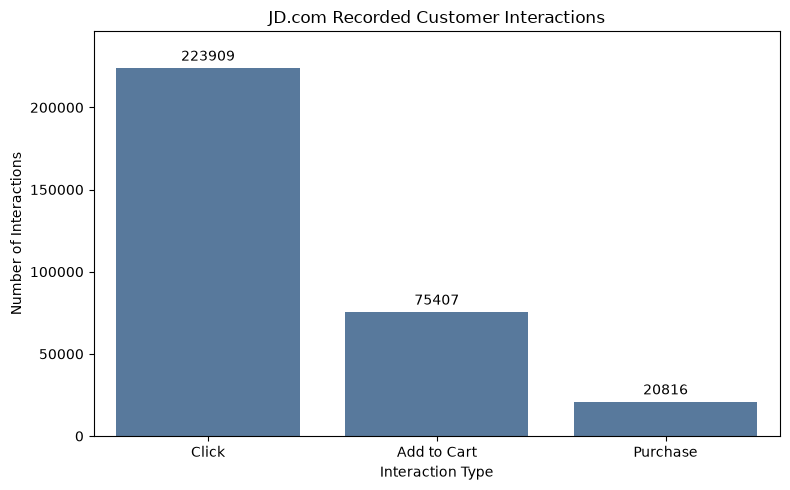

In [19]:
interaction_summary = clean_df["interaction_type"].value_counts().rename_axis("interaction_type").reset_index(name="interaction_count")

plt.figure(figsize=(8, 5))
chart = sns.barplot(data=interaction_summary, x="interaction_type", y="interaction_count", color="#4C78A8")
chart.bar_label(chart.containers[0], fmt="%.0f", padding=3)
chart.margins(y=0.1)

plt.title("JD.com Recorded Customer Interactions")
plt.xlabel("Interaction Type")
plt.ylabel("Number of Interactions")
plt.ticklabel_format(style="plain", axis="y")
plt.tight_layout()
plt.show()

<Axes: xlabel='interaction_type'>

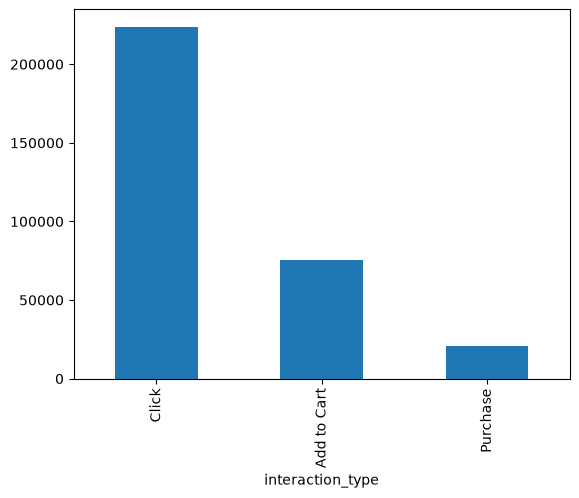

In [20]:
interaction_summary.plot.bar(x="interaction_type", y="interaction_count", legend=False)

### Interaction Analysis — Key Finding

Clicks account for the majority of recorded positive interactions, followed by cart additions and purchases. Purchases represent approximately 6.50% of the analyzed interaction records.

This establishes the project's overall Purchase Share baseline and provides a reference point for comparing categories, brands, shops, products, and queries.

## Category Analysis

Category-level analysis evaluates differences in customer activity and purchase representation across product categories.

For each category, the analysis calculates total interactions, clicks, cart additions, purchases, unique products, and Purchase Share. Categories are then examined from two perspectives:

1. categories generating the highest number of purchases; and
2. categories with meaningful interaction volume but relatively low Purchase Share.

A minimum interaction threshold is used when identifying potential opportunities so that very small groups do not receive disproportionate attention.

In [21]:
category_performance = (
    clean_df.groupby("category_level_4_id")
    .agg(
        total_interactions=("interaction_label", "size"),
        clicks=("interaction_label", lambda x: (x == 1).sum()),
        cart_additions=("interaction_label", lambda x: (x == 2).sum()),
        purchases=("interaction_label", lambda x: (x == 3).sum()),
        unique_products=("product_id", "nunique")
    )
    .reset_index()
)

category_performance["purchase_share_percent"] = (
    category_performance["purchases"]
    / category_performance["total_interactions"]
    * 100
).round(2)

category_performance.head()

,category_level_4_id,total_interactions,clicks,cart_additions,purchases,unique_products,purchase_share_percent
0,10012818,11,7,2,2,10,18.18
1,10077835,12,7,3,2,12,16.67
2,10092864,96,71,21,4,83,4.17
3,10105618,102,52,41,9,58,8.82
4,10138475,695,501,120,74,604,10.65


In [22]:
top_categories_by_purchases = (
    category_performance
    .sort_values("purchases", ascending=False)
    .head(15)
)

top_categories_by_purchases

,category_level_4_id,total_interactions,clicks,cart_additions,purchases,unique_products,purchase_share_percent
3578,77255620,1052,545,322,185,473,17.59
3679,7929383,1430,966,287,177,1175,12.38
1818,44610525,807,423,211,173,405,21.44
2470,56253428,2700,1964,567,169,1471,6.26
1739,43234307,1393,811,415,167,960,11.99
2177,50615933,891,495,232,164,564,18.41
1125,32130995,2479,1886,433,160,2279,6.45
3460,74945795,812,466,196,150,679,18.47
1924,462318,14803,10540,4117,146,4571,0.99
3826,82092464,1475,874,458,143,863,9.69


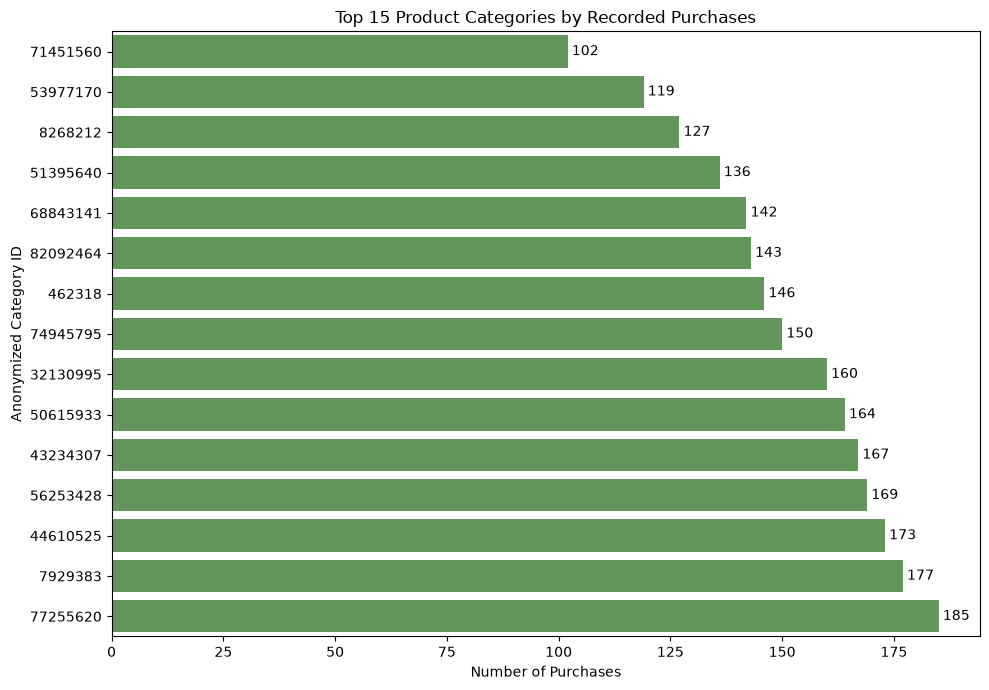

In [23]:
chart_data = top_categories_by_purchases.sort_values(
    "purchases",
    ascending=True
)

plt.figure(figsize=(10, 7))

chart = sns.barplot(
    data=chart_data,
    x="purchases",
    y="category_level_4_id",
    color="#59A14F"
)

chart.bar_label(chart.containers[0], fmt="%.0f", padding=3)

plt.title("Top 15 Product Categories by Recorded Purchases")
plt.xlabel("Number of Purchases")
plt.ylabel("Anonymized Category ID")
plt.tight_layout()
plt.show()

In [24]:
high_opportunity_categories = (
    category_performance[
        category_performance["total_interactions"] >= 100
    ]
    .sort_values(
        ["purchase_share_percent", "purchases"],
        ascending=[False, False]
    )
    .head(15)
)

high_opportunity_categories

,category_level_4_id,total_interactions,clicks,cart_additions,purchases,unique_products,purchase_share_percent
4066,86334965,109,46,26,37,72,33.94
3777,80974640,215,98,56,61,111,28.37
3033,66895855,155,62,50,43,51,27.74
3508,75929435,193,79,61,53,69,27.46
1797,44140188,123,51,40,32,88,26.02
4594,96704406,164,81,41,42,100,25.61
1310,35662908,134,59,41,34,104,25.37
1651,41838728,131,63,35,33,96,25.19
4445,93815500,113,47,38,28,57,24.78
4719,99185081,158,69,50,39,86,24.68


### Category Analysis — Interpretation

Category performance is distributed across a large number of anonymized categories rather than being concentrated in only a few segments. High interaction volume does not always correspond with high Purchase Share.

Categories with substantial engagement but comparatively low Purchase Share should therefore be treated as investigation priorities rather than assumed performance failures. Additional information on pricing, availability, search ranking, product content, and linked customer journeys would be needed to determine the underlying cause.

## Brand and Shop Analysis

The next stage compares interaction and purchase activity across anonymized brands and shops.

Brand-level metrics are calculated using the same framework as category analysis. Shop-level analysis excludes the `-1` shop identifier, which represents an invalid or unavailable shop value rather than a meaningful seller.

The analysis identifies both strong performers and segments with sufficient activity but relatively low Purchase Share. These results can help prioritize brands or sellers for deeper investigation.

In [25]:
brand_performance = (
    clean_df.groupby("brand_id")
    .agg(
        total_interactions=("interaction_label", "size"),
        clicks=("interaction_label", lambda x: (x == 1).sum()),
        cart_additions=("interaction_label", lambda x: (x == 2).sum()),
        purchases=("interaction_label", lambda x: (x == 3).sum()),
        unique_products=("product_id", "nunique")
    )
    .reset_index()
)

brand_performance["purchase_share_percent"] = (
    brand_performance["purchases"]
    / brand_performance["total_interactions"]
    * 100
).round(2)

brand_performance.head()

,brand_id,total_interactions,clicks,cart_additions,purchases,unique_products,purchase_share_percent
0,10001457,4,4,0,0,3,0.0
1,10001469,2,1,1,0,2,0.0
2,10002653,2,2,0,0,2,0.0
3,1000578,1,0,0,1,1,100.0
4,10005786,1,1,0,0,1,0.0


In [26]:
top_brands_by_purchases = (
    brand_performance
    .sort_values("purchases", ascending=False)
    .head(15)
)

top_brands_by_purchases

,brand_id,total_interactions,clicks,cart_additions,purchases,unique_products,purchase_share_percent
23602,54289642,4538,3185,1049,304,4271,6.70
11605,31775854,1713,959,465,289,1210,16.87
26794,60333963,1309,811,317,181,692,13.83
24617,56184183,3941,2778,986,177,1687,4.49
27215,61085683,3595,2475,975,145,1936,4.03
22864,52967698,2315,1666,535,114,1168,4.92
35236,76193000,1066,757,199,110,802,10.32
30438,67072585,8813,6071,2633,109,2365,1.24
12396,33241674,5394,3944,1348,102,2364,1.89
15278,38645246,4495,3603,794,98,4385,2.18


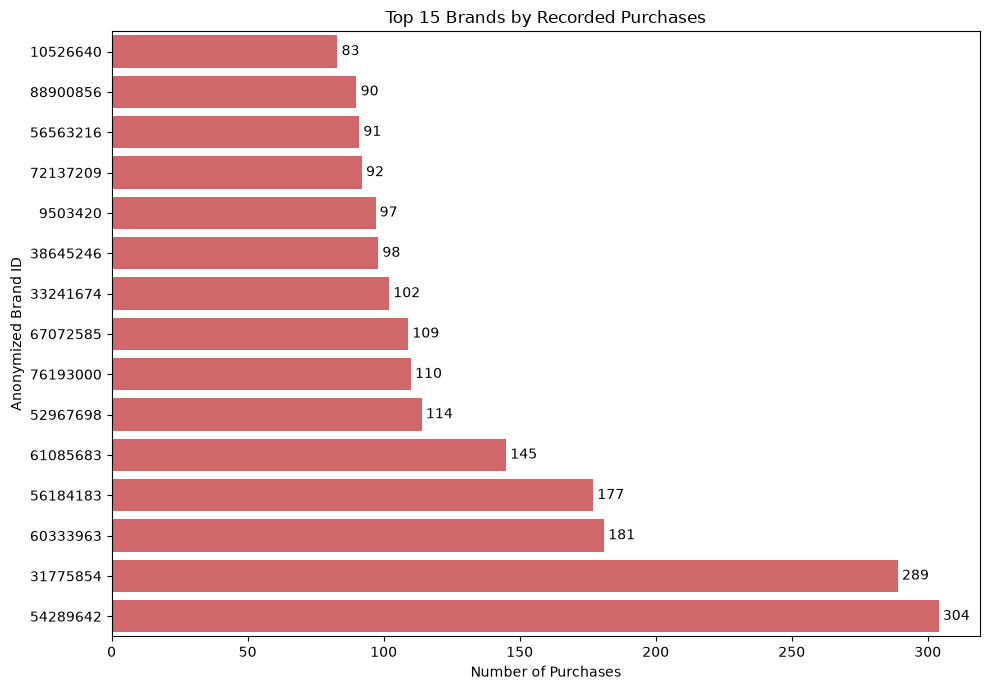

In [27]:
chart_data = top_brands_by_purchases.sort_values(
    "purchases",
    ascending=True
)

plt.figure(figsize=(10, 7))

chart = sns.barplot(
    data=chart_data,
    x="purchases",
    y="brand_id",
    color="#E15759"
)

chart.bar_label(chart.containers[0], fmt="%.0f", padding=3)

plt.title("Top 15 Brands by Recorded Purchases")
plt.xlabel("Number of Purchases")
plt.ylabel("Anonymized Brand ID")
plt.tight_layout()
plt.show()

In [28]:
high_opportunity_brands = (
    brand_performance[
        brand_performance["total_interactions"] >= 100
    ]
    .sort_values(
        ["purchase_share_percent", "purchases"],
        ascending=[False, False]
    )
    .head(15)
)

high_opportunity_brands

,brand_id,total_interactions,clicks,cart_additions,purchases,unique_products,purchase_share_percent
6557,22357719,118,44,38,36,28,30.51
44379,93609875,128,45,46,37,84,28.91
37651,80806344,143,53,49,41,77,28.67
43976,92785000,130,55,39,36,79,27.69
13851,35922244,118,49,38,31,65,26.27
35149,76003383,123,57,34,32,54,26.02
38377,82202449,120,55,36,29,50,24.17
34074,7398206,289,128,92,69,161,23.88
8912,2683940,296,130,96,70,131,23.65
46320,97268014,168,77,52,39,78,23.21


In [29]:
shop_performance = (
    clean_df[clean_df["shop_id"] != "-1"]
    .groupby("shop_id")
    .agg(
        total_interactions=("interaction_label", "size"),
        clicks=("interaction_label", lambda x: (x == 1).sum()),
        cart_additions=("interaction_label", lambda x: (x == 2).sum()),
        purchases=("interaction_label", lambda x: (x == 3).sum()),
        unique_products=("product_id", "nunique")
    )
    .reset_index()
)

shop_performance["purchase_share_percent"] = (
    shop_performance["purchases"]
    / shop_performance["total_interactions"]
    * 100
).round(2)

shop_performance.head()

,shop_id,total_interactions,clicks,cart_additions,purchases,unique_products,purchase_share_percent
0,10000728,1,1,0,0,1,0.0
1,10000864,1,1,0,0,1,0.0
2,10001144,2,2,0,0,2,0.0
3,10001469,3,2,1,0,3,0.0
4,10002253,1,1,0,0,1,0.0


In [30]:
top_shops_by_purchases = (
    shop_performance
    .sort_values("purchases", ascending=False)
    .head(15)
)

top_shops_by_purchases

,shop_id,total_interactions,clicks,cart_additions,purchases,unique_products,purchase_share_percent
67096,86521100,2679,1307,892,480,1511,17.92
29835,44190315,3157,2066,870,221,622,7.00
49807,66803780,1281,798,313,170,676,13.27
71116,91090886,702,336,201,165,413,23.50
71690,91770864,675,294,259,122,326,18.07
29401,43711593,1841,1228,515,98,557,5.32
76137,9682594,4423,2747,1588,88,309,1.99
67326,86774987,371,178,111,82,160,22.10
37647,53042237,314,134,100,80,52,25.48
8647,19862480,328,161,96,71,216,21.65


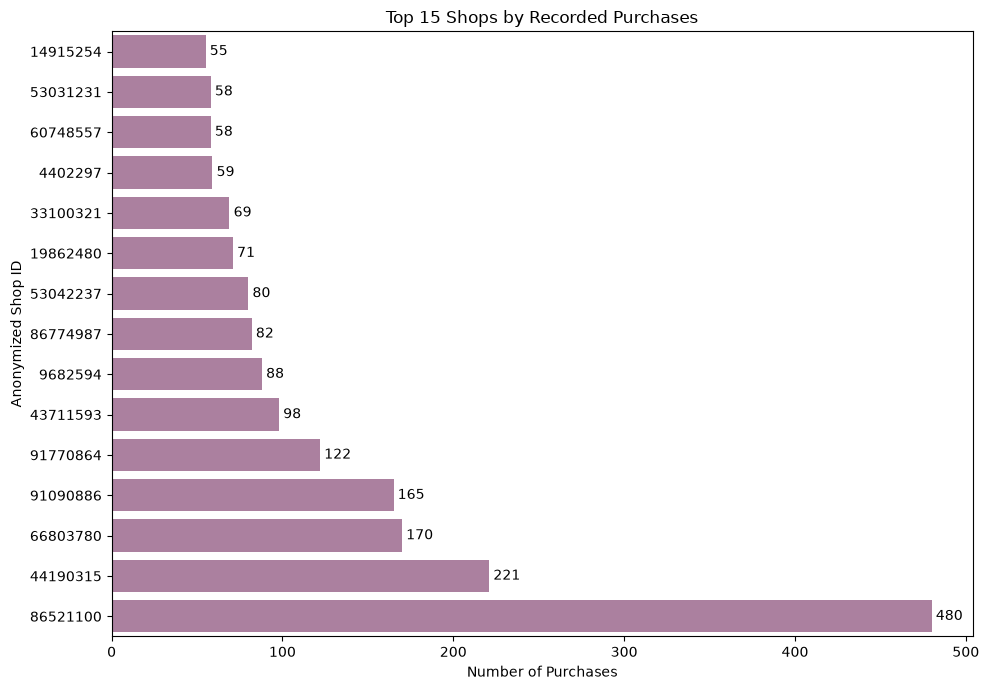

In [31]:
chart_data = top_shops_by_purchases.sort_values(
    "purchases",
    ascending=True
)

plt.figure(figsize=(10, 7))

chart = sns.barplot(
    data=chart_data,
    x="purchases",
    y="shop_id",
    color="#B279A2"
)

chart.bar_label(chart.containers[0], fmt="%.0f", padding=3)

plt.title("Top 15 Shops by Recorded Purchases")
plt.xlabel("Number of Purchases")
plt.ylabel("Anonymized Shop ID")
plt.tight_layout()
plt.show()


In [32]:
shops_needing_attention = (
    shop_performance[
        shop_performance["total_interactions"] >= 100
    ]
    .sort_values(
        ["purchase_share_percent", "total_interactions"],
        ascending=[True, False]
    )
    .head(15)
)

shops_needing_attention

,shop_id,total_interactions,clicks,cart_additions,purchases,unique_products,purchase_share_percent
7607,18716623,502,199,303,0,47,0.0
18027,30799657,415,370,45,0,380,0.0
46213,62793388,248,213,35,0,157,0.0
26881,40852916,225,203,22,0,209,0.0
3386,13821585,203,167,36,0,154,0.0
66105,85371717,170,91,79,0,55,0.0
70340,90216623,170,146,24,0,131,0.0
8694,19915131,152,100,52,0,27,0.0
1126,11277674,138,106,32,0,98,0.0
74102,94486177,138,90,48,0,49,0.0


### Brand and Shop Analysis — Interpretation

The results show that engagement and purchase representation vary considerably across brands and sellers. High activity alone does not guarantee a high proportion of purchases.

These differences are descriptive and should not be interpreted as evidence that a brand or seller caused stronger or weaker purchasing behavior. Factors such as product mix, pricing, availability, search visibility, and customer intent may contribute to the observed differences.

## Product Analysis

Product-level analysis examines which individual products generate the most purchase activity and which products may warrant additional investigation.

Metrics include total interactions, clicks, cart additions, purchases, Purchase Share, associated brand, category, shop, and query activity.

Product-level results require additional caution because many products appear only a small number of times in the dataset. A minimum interaction threshold is therefore used when identifying potential underperforming products to reduce the influence of extremely sparse records.

In [33]:
product_performance = (
    clean_df.groupby(
        [
            "product_id",
            "brand_id",
            "category_level_4_id",
            "shop_id"
        ],
        dropna=False
    )
    .agg(
        total_interactions=("interaction_label", "size"),
        clicks=("interaction_label", lambda x: (x == 1).sum()),
        cart_additions=("interaction_label", lambda x: (x == 2).sum()),
        purchases=("interaction_label", lambda x: (x == 3).sum()),
        unique_query_records=("query_record_id", "nunique")
    )
    .reset_index()
)

product_performance["purchase_share_percent"] = (
    product_performance["purchases"]
    / product_performance["total_interactions"]
    * 100
).round(2)

product_performance.head()

product_performance["purchase_share_percent"] = (
    product_performance["purchases"]
    / product_performance["total_interactions"]
    * 100
).round(2)

product_performance.head()

,product_id,brand_id,category_level_4_id,shop_id,total_interactions,clicks,cart_additions,purchases,unique_query_records,purchase_share_percent
0,10000126,88819654,57552570,49752242,2,2,0,0,2,0.0
1,10001475,30853043,22195176,71615334,1,1,0,0,1,0.0
2,10001695,4959677,65122228,92506264,1,1,0,0,1,0.0
3,10002738,22262984,53531192,47104222,1,1,0,0,1,0.0
4,10002987,47267224,23944182,19253972,1,0,1,0,1,0.0


In [34]:
top_products_by_purchases = (
    product_performance
    .sort_values(
        ["purchases", "total_interactions"],
        ascending=[False, False]
    )
    .head(15)
)

top_products_by_purchases


,product_id,brand_id,category_level_4_id,shop_id,total_interactions,clicks,cart_additions,purchases,unique_query_records,purchase_share_percent
37434,24157445,67072585,462318,9682594,191,85,93,13,32,6.81
175083,76456085,88900856,77255620,53042237,47,17,17,13,19,27.66
110088,51799947,2519324,24964104,16876338,29,13,3,13,7,44.83
58069,31983436,72361705,4179153,66714215,34,15,7,12,18,35.29
31293,21819663,79498931,44610525,3058607,32,12,8,12,14,37.50
182862,79367384,67072585,53704463,9682594,101,65,25,11,47,10.89
173690,75921052,65035141,62274523,70254080,41,21,9,11,18,26.83
54336,30552656,37708415,89850585,87422494,38,16,11,11,27,28.95
209534,89407419,88900856,77255620,53042237,32,11,10,11,10,34.38
27813,20469820,65347088,56253428,53997937,40,24,6,10,18,25.00


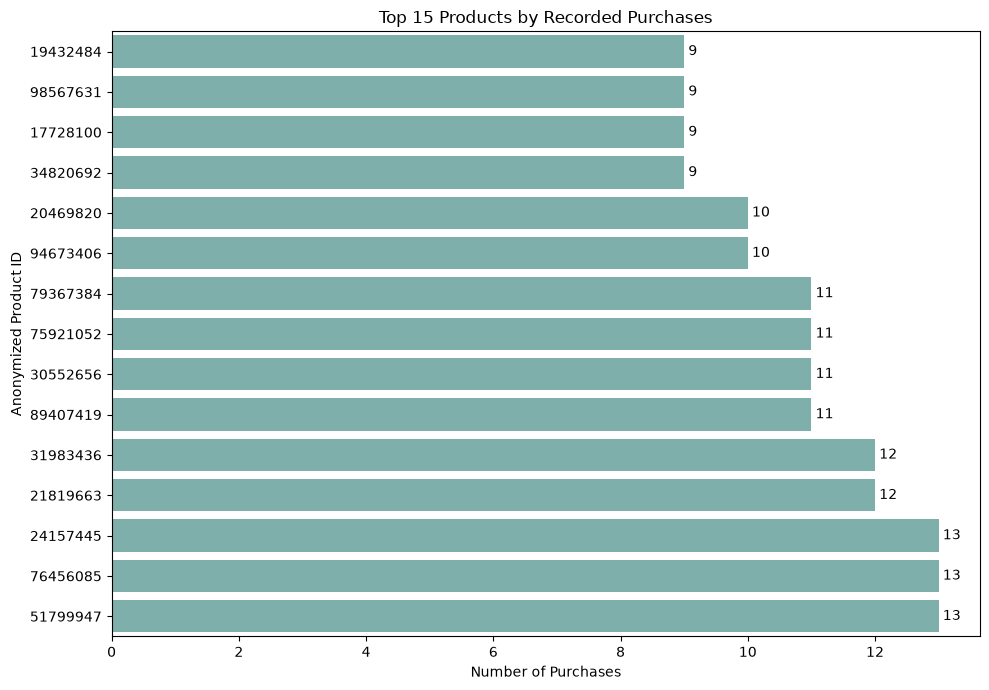

In [35]:
chart_data = top_products_by_purchases.sort_values(
    "purchases",
    ascending=True
)

plt.figure(figsize=(10, 7))

chart = sns.barplot(
    data=chart_data,
    x="purchases",
    y="product_id",
    color="#76B7B2"
)

chart.bar_label(chart.containers[0], fmt="%.0f", padding=3)

plt.title("Top 15 Products by Recorded Purchases")
plt.xlabel("Number of Purchases")
plt.ylabel("Anonymized Product ID")
plt.tight_layout()
plt.show()

In [36]:
products_needing_attention = (
    product_performance[
        product_performance["total_interactions"] >= 20
    ]
    .sort_values(
        ["purchase_share_percent", "total_interactions"],
        ascending=[True, False]
    )
    .head(20)
)

products_needing_attention

,product_id,brand_id,category_level_4_id,shop_id,total_interactions,clicks,cart_additions,purchases,unique_query_records,purchase_share_percent
231878,97745171,48223324,22195176,18716623,396,117,279,0,55,0.0
63769,34165613,67072585,462318,9682594,163,127,36,0,37,0.0
214402,9122301,67072585,462318,27181112,129,94,35,0,26,0.0
225894,9552718,67072585,462318,9682594,100,46,54,0,22,0.0
146227,65601524,67072585,462318,9682594,93,72,21,0,19,0.0
9496,13520942,45709906,462318,34032164,89,56,33,0,27,0.0
140114,63295078,56184183,462318,44190315,87,62,25,0,27,0.0
33978,22854957,67072585,462318,9682594,77,61,16,0,24,0.0
43398,26445318,33241674,462318,93465611,72,55,17,0,19,0.0
135908,61706928,33486833,56552421,47981605,69,40,29,0,22,0.0


In [37]:
cart_opportunity_products = (
    product_performance[
        product_performance["cart_additions"] >= 10
    ]
    .assign(
        cart_purchase_share=lambda x: (
            x["purchases"]
            / (x["cart_additions"] + x["purchases"])
            * 100
        ).round(2)
    )
    .sort_values(
        ["cart_purchase_share", "cart_additions"],
        ascending=[True, False]
    )
    .head(20)
)

cart_opportunity_products

,product_id,brand_id,category_level_4_id,shop_id,total_interactions,clicks,cart_additions,purchases,unique_query_records,purchase_share_percent,cart_purchase_share
231878,97745171,48223324,22195176,18716623,396,117,279,0,55,0.0,0.0
225894,9552718,67072585,462318,9682594,100,46,54,0,22,0.0,0.0
63769,34165613,67072585,462318,9682594,163,127,36,0,37,0.0,0.0
214402,9122301,67072585,462318,27181112,129,94,35,0,26,0.0,0.0
9496,13520942,45709906,462318,34032164,89,56,33,0,27,0.0,0.0
135908,61706928,33486833,56552421,47981605,69,40,29,0,22,0.0,0.0
47325,279320,67072585,94281717,9682594,40,14,26,0,15,0.0,0.0
140114,63295078,56184183,462318,44190315,87,62,25,0,27,0.0,0.0
231407,97580680,67072585,462318,41287659,59,35,24,0,24,0.0,0.0
66516,35207812,50353271,462318,94260409,35,13,22,0,14,0.0,0.0


### Product Analysis — Interpretation

Product-level performance is highly sparse, so rankings based on very small numbers of interactions should not be treated as reliable indicators of product quality or customer preference.

Products with meaningful activity and comparatively low Purchase Share provide stronger candidates for investigation. Possible areas for follow-up include product-page information, price competitiveness, inventory availability, shipping conditions, and search-result positioning.

## Query Analysis

Query-level analysis examines the relationship between anonymized search queries and recorded customer interactions.

For each tokenized query, the analysis calculates total interactions, clicks, cart additions, purchases, unique products, and Purchase Share. Queries are reviewed by overall activity, purchase volume, relatively low Purchase Share, and relatively high purchase representation.

Because query text is tokenized, this analysis can identify which query IDs deserve further investigation but cannot directly explain the customer's search intent.

In [38]:
query_performance = (
    clean_df.groupby(
        "query_record_id",
        dropna=False
    )
    .agg(
        total_interactions=("interaction_label", "size"),
        clicks=("interaction_label", lambda x: (x == 1).sum()),
        cart_additions=("interaction_label", lambda x: (x == 2).sum()),
        purchases=("interaction_label", lambda x: (x == 3).sum()),
        unique_products=("product_id", "nunique")
    )
    .reset_index()
)

query_performance["purchase_share_percent"] = (
    query_performance["purchases"]
    / query_performance["total_interactions"]
    * 100
).round(2)

query_performance.head()

,query_record_id,total_interactions,clicks,cart_additions,purchases,unique_products,purchase_share_percent
0,0,1,1,0,0,1,0.0
1,1,2,2,0,0,2,0.0
2,10,9,7,2,0,8,0.0
3,100,2,2,0,0,2,0.0
4,1000,1,1,0,0,1,0.0


In [39]:
top_queries_by_activity = (
    query_performance
    .sort_values("total_interactions", ascending=False)
    .head(15)
)

top_queries_by_activity

,query_record_id,total_interactions,clicks,cart_additions,purchases,unique_products,purchase_share_percent
49817,4488,581,410,166,5,373,0.86
20240,18,498,312,184,2,144,0.40
109294,99,475,261,196,18,89,3.79
27558,2465,275,191,78,6,188,2.18
67663,611,264,199,63,2,96,0.76
79977,723,243,189,53,1,195,0.41
15507,137,241,132,107,2,59,0.83
95140,861,238,171,34,33,170,13.87
12785,1123,237,160,57,20,107,8.44
34000,305,210,79,73,58,138,27.62


In [40]:
top_queries_by_purchases = (
    query_performance
    .sort_values(
        ["purchases", "total_interactions"],
        ascending=[False, False]
    )
    .head(15)
)

top_queries_by_purchases

,query_record_id,total_interactions,clicks,cart_additions,purchases,unique_products,purchase_share_percent
34000,305,210,79,73,58,138,27.62
52267,471,204,114,39,51,127,25.00
95140,861,238,171,34,33,170,13.87
50127,4516,82,30,19,33,39,40.24
96458,873,83,25,26,32,72,38.55
36032,3234,141,63,47,31,94,21.99
24721,2207,117,50,36,31,66,26.50
60083,542,139,71,40,28,109,20.14
29541,2645,42,7,7,28,36,66.67
24632,2199,125,57,41,27,81,21.60


In [41]:
underserved_queries = (
    query_performance[
        query_performance["total_interactions"] >= 20
    ]
    .sort_values(
        ["purchase_share_percent", "total_interactions"],
        ascending=[True, False]
    )
    .head(20)
)

underserved_queries

,query_record_id,total_interactions,clicks,cart_additions,purchases,unique_products,purchase_share_percent
51867,4674,155,106,49,0,106,0.0
35743,3208,140,115,25,0,44,0.0
12422,1113,136,105,31,0,50,0.0
85134,77,127,108,19,0,59,0.0
10985,11,118,90,28,0,40,0.0
17722,1571,115,56,59,0,16,0.0
79103,715,97,72,25,0,37,0.0
24379,2176,89,63,26,0,33,0.0
82064,742,89,55,34,0,73,0.0
13841,1219,88,72,16,0,35,0.0


In [42]:
high_intent_queries = (
    query_performance[
        query_performance["total_interactions"] >= 20
    ]
    .sort_values(
        ["purchase_share_percent", "purchases"],
        ascending=[False, False]
    )
    .head(20)
)

high_intent_queries

,query_record_id,total_interactions,clicks,cart_additions,purchases,unique_products,purchase_share_percent
29541,2645,42,7,7,28,36,66.67
14889,1314,37,7,11,19,23,51.35
44959,4045,33,11,6,16,27,48.48
29893,2677,27,11,3,13,12,48.15
18828,16716,24,9,4,11,19,45.83
61638,5561,20,4,7,9,14,45.00
74767,6756,20,6,5,9,14,45.00
13522,119,25,8,6,11,10,44.00
54293,4894,41,14,9,18,24,43.90
79868,722,39,16,6,17,31,43.59


### Query Analysis — Interpretation

Search-query performance varies substantially across the dataset. Some queries generate considerable activity but relatively little purchase representation, while others show stronger purchase composition.

These results may indicate opportunities to investigate search relevance, product-result quality, ranking, availability, or customer intent. However, the anonymized query content prevents direct interpretation of what customers were searching for.

## Limitations

Several limitations affect how these findings should be interpreted.

The dataset includes only positive interaction labels and therefore does not provide impression-level or visitor-level conversion measurement. Individual records are not linked into customer journeys, so clicks, cart additions, and purchases cannot be interpreted as sequential funnel stages.

The data also lacks timestamps, financial measures, pricing, inventory status, shipping information, returns, cancellations, and other contextual variables that could explain differences in purchase behavior.

Product, brand, shop, category, and query identifiers are anonymized, and query content is tokenized. Exact duplicate records are present, but the absence of timestamps or a unique event identifier prevents them from being conclusively classified as erroneous duplicate events. Sensitivity analysis shows that removing them does not materially alter the headline Purchase Share result.

Finally, the analysis is descriptive and exploratory. Observed relationships should be treated as prioritization signals rather than evidence of causation.

## Key Takeaways

The analysis produced several important findings:

- Recorded interactions are dominated by clicks, while purchases account for approximately 6.50% of positive interaction records.
- Purchase activity is distributed across a large number of categories, brands, shops, products, and queries rather than being dominated by only a handful of entities.
- High interaction volume does not consistently correspond with high Purchase Share.
- Segments combining meaningful engagement with relatively low Purchase Share provide useful candidates for deeper investigation.
- Product-level results should be interpreted cautiously because interaction counts are highly sparse for many individual products.
- Duplicate-row sensitivity testing indicates that retaining exact repeated records does not materially alter the headline Purchase Share interpretation.

The findings support prioritizing selected categories, brands, shops, products, and queries for further investigation rather than assuming that observed performance differences have a single cause. Stronger conclusions would require linked customer journeys and additional information such as impressions, timestamps, pricing, inventory, shipping, and financial outcomes.

## Analytical Outputs

The final cleaned interaction dataset and aggregated performance tables are exported for use in PostgreSQL, Tableau, and the project's supporting documentation.

Outputs include category, brand, shop, product, and query performance tables as well as the cleaned interaction-level dataset.

In [43]:
category_performance.to_csv("category_performance.csv", index=False)
brand_performance.to_csv("brand_performance.csv", index=False)
shop_performance.to_csv("shop_performance.csv", index=False)
product_performance.to_csv("product_performance.csv", index=False)
query_performance.to_csv("query_performance.csv", index=False)

print("Analytical tables saved successfully.")

Analytical tables saved successfully.


In [44]:
clean_df.to_csv(
    "jdsearch_cleaned_interactions.csv",
    index=False
)

print("CSV created successfully.")


CSV created successfully.


In [45]:
import os
print(os.path.abspath("jdsearch_cleaned_interactions.csv"))


/Users/britneygraham/Documents/Data_Analyst_Portfolio/Project1_JD.com/JDcom_Customer_Analytics/jdsearch_cleaned_interactions.csv
